In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Master's Golf tournament round scores (2021-2026)

In [2]:
df = pd.read_csv("masters.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (536, 6)


,year,player,R1,R2,R3,R4
0,2026,Rory McIlroy,67,65,73,71
1,2026,Scottie Scheffler,70,74,65,68
2,2026,Justin Rose,70,69,69,70
3,2026,Cameron Young,73,67,65,73
4,2026,Tyrrell Hatton,74,66,72,66


In [3]:
# Convert R3 and R4 to numeric, turning missing values / cut symbols ('-') into NaN
round_cols = ["R1", "R2", "R3", "R4"]
for col in round_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["made_cut"] = df["R3"].notna() & df["R4"].notna()

print(f"Total starting players: {len(df)}")
print(f"Players who made the cut (completed 4 rounds): {df['made_cut'].sum()}")
df.head()

Total starting players: 536
Players who made the cut (completed 4 rounds): 326


,year,player,R1,R2,R3,R4,made_cut
0,2026,Rory McIlroy,67,65,73.0,71.0,True
1,2026,Scottie Scheffler,70,74,65.0,68.0,True
2,2026,Justin Rose,70,69,69.0,70.0,True
3,2026,Cameron Young,73,67,65.0,73.0,True
4,2026,Tyrrell Hatton,74,66,72.0,66.0,True


In [4]:
summary_stats = df[round_cols].describe().T
print(summary_stats)

    count       mean       std   min    25%   50%   75%   max
R1  536.0  73.722015  3.343170  65.0  71.75  74.0  76.0  90.0
R2  536.0  73.449627  3.340670  65.0  71.00  73.0  75.0  85.0
R3  326.0  72.972393  3.099753  65.0  71.00  73.0  75.0  82.0
R4  326.0  72.447853  3.216598  64.0  70.00  72.0  74.0  84.0


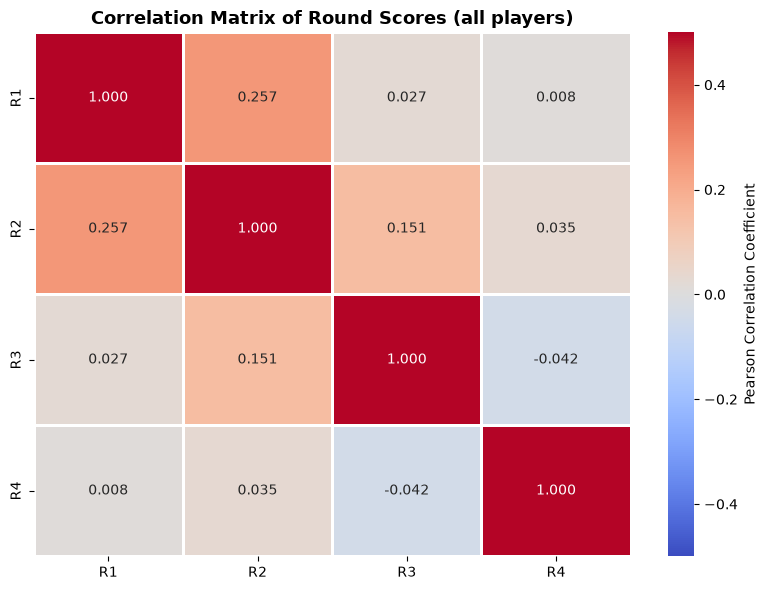

In [5]:
# Calculate Pearson correlation matrix
corr_matrix = df[round_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Display numeric correlation values
    fmt=".3f",           # Format numbers to 3 decimal places
    cmap="coolwarm",     # Color palette (blue = negative, red = positive)
    vmin=-0.5,           # Set colorbar lower limit
    vmax=0.5,            # Set colorbar upper limit
    linewidths=1,        # Gridline spacing between cells
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)

plt.title("Correlation Matrix of Round Scores (all players)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [6]:
model= smf.ols('R2 ~ R1', data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                     R2   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     37.84
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.51e-09
Time:                        07:20:34   Log-Likelihood:                -1388.2
No. Observations:                 536   AIC:                             2780.
Df Residuals:                     534   BIC:                             2789.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     54.5001      3.084     17.673      0.0

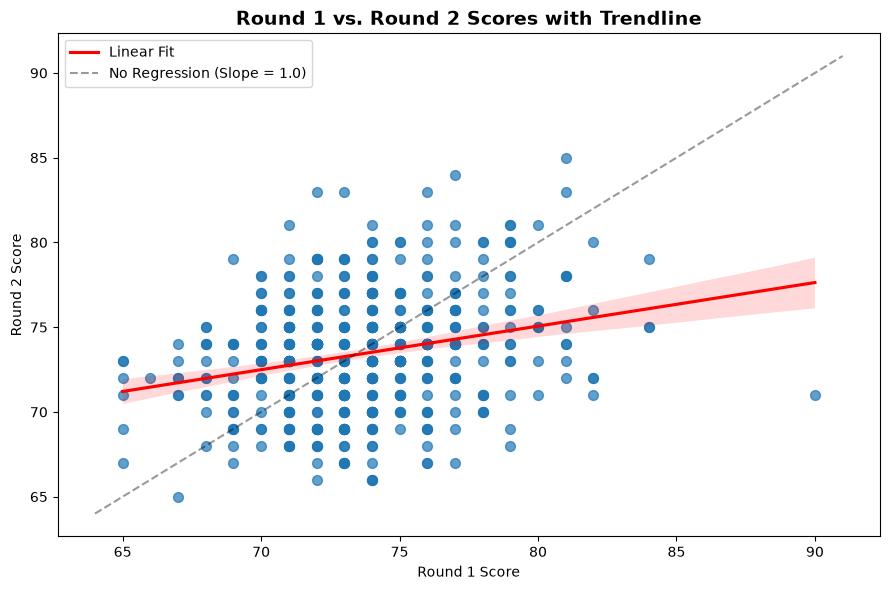

Fitted Slope: 0.257
Interpretation: For every 1-stroke improvement below the mean in R1, players only retained ~0.26 strokes of that improvement in R2.


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=df, 
    x="R1", 
    y="R2", 
    ax=ax, 
    scatter_kws={"alpha": 0.7, "s": 50}, 
    line_kws={"color": "red", "label": "Linear Fit"}
)

# Reference 1:1 identity line
min_val = min(df["R1"].min(), df["R2"].min()) - 1
max_val = max(df["R1"].max(), df["R2"].max()) + 1
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label="No Regression (Slope = 1.0)")

ax.set_title("Round 1 vs. Round 2 Scores with Trendline", fontsize=14, fontweight="bold")
ax.set_xlabel("Round 1 Score")
ax.set_ylabel("Round 2 Score")
ax.legend()
plt.tight_layout()
plt.show()

# Fit slope calculation
slope, intercept = np.polyfit(df["R1"], df["R2"], 1)
print(f"Fitted Slope: {slope:.3f}")
print(f"Interpretation: For every 1-stroke improvement below the mean in R1, players only retained ~{slope:.2f} strokes of that improvement in R2.")

In [8]:
# just players that played all 4  (made the cut)
df_cut = df[df["made_cut"]]
print(df_cut.shape)


(326, 7)


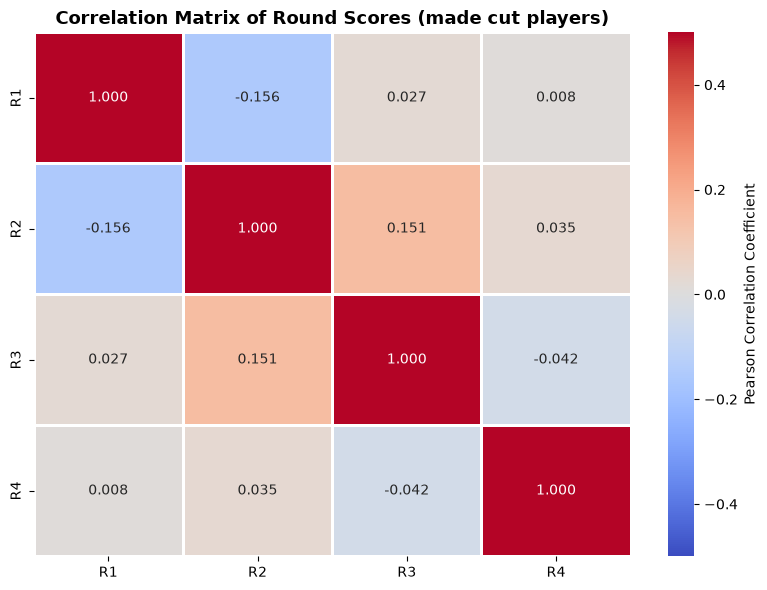

In [9]:
corr_matrix = df_cut[round_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Display numeric correlation values
    fmt=".3f",           # Format numbers to 3 decimal places
    cmap="coolwarm",     # Color palette (blue = negative, red = positive)
    vmin=-0.5,           # Set colorbar lower limit
    vmax=0.5,            # Set colorbar upper limit
    linewidths=1,        # Gridline spacing between cells
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)

plt.title("Correlation Matrix of Round Scores (made cut players)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# curiously - stronger correlation between R2 and R3


## curiously - stronger correlation between R2 and R3
AI says:
Saturday is traditionally "Moving Day." Players who scored well on Friday carry immediate tactical confidence into Saturday, while players who barely made the cut often continue playing with the "house money" mindset that got them through Friday's round.

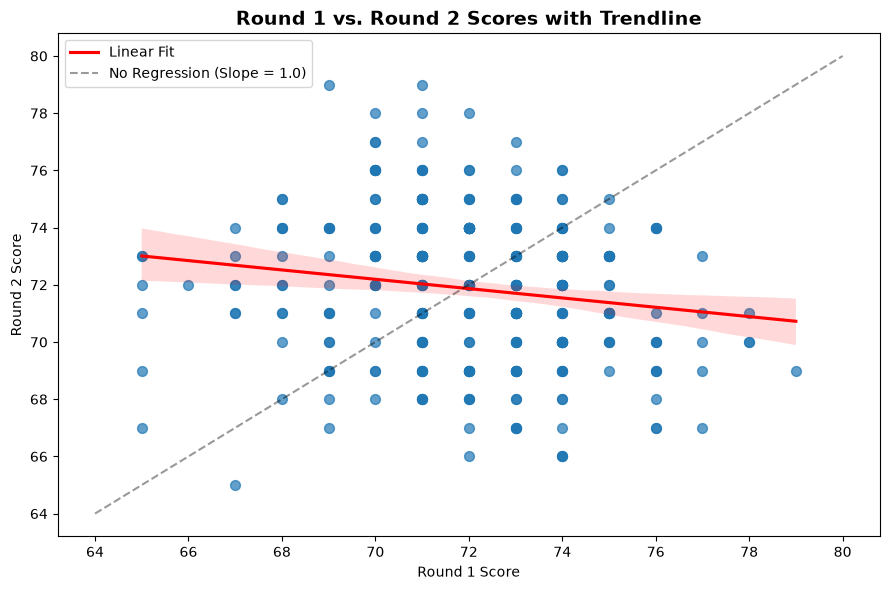

Fitted Slope: -0.163


In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=df_cut, 
    x="R1", 
    y="R2", 
    ax=ax, 
    scatter_kws={"alpha": 0.7, "s": 50}, 
    line_kws={"color": "red", "label": "Linear Fit"}
)

# Reference 1:1 identity line
min_val = min(df_cut["R1"].min(), df_cut["R2"].min()) - 1
max_val = max(df_cut["R1"].max(), df_cut["R2"].max()) + 1
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label="No Regression (Slope = 1.0)")

ax.set_title("Round 1 vs. Round 2 Scores with Trendline", fontsize=14, fontweight="bold")
ax.set_xlabel("Round 1 Score")
ax.set_ylabel("Round 2 Score")
ax.legend()
plt.tight_layout()
plt.show()

# Fit slope calculation
slope, intercept = np.polyfit(df_cut["R1"], df_cut["R2"], 1)
print(f"Fitted Slope: {slope:.3f}")


# Illustrate Berkman's paradox
Overall, there is positive correlation between R1 and R2.
Better players may regress to personal means, but should still perform better than worse players.
But for those that survive the cut, correlation between R1 and R2 is negative

Text(0, 0.5, 'Round 2 Score')

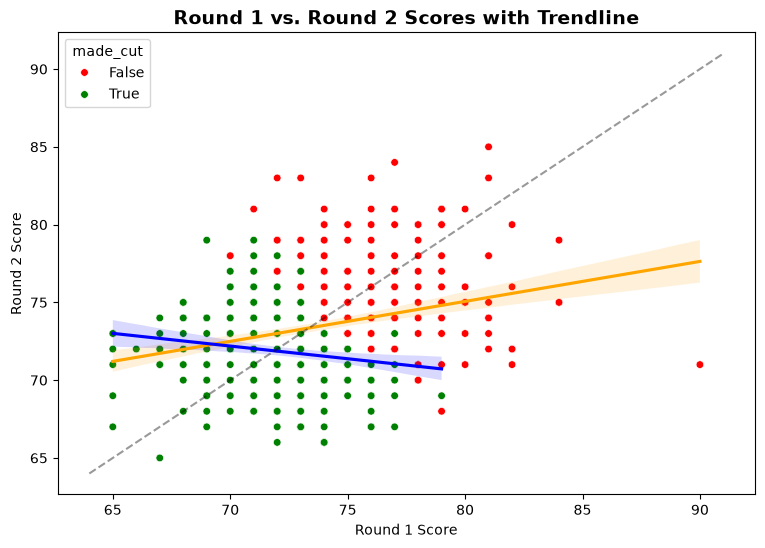

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

# scatter separately to get colors
sns.scatterplot(data=df, x="R1", y="R2", 
                hue="made_cut", 
                palette={True: "green", False: "red"}, 
                s=30)

sns.regplot(
    data=df, 
    x="R1", 
    y="R2", 
    ax=ax, 
    scatter=False,
    line_kws={"color": "orange", "label": "Linear Fit"}
)

sns.regplot(
    data=df_cut, 
    x="R1", 
    y="R2", 
    ax=ax, 
    scatter=False,
    line_kws={"color": "blue", "label": "Linear Fit"}
)

# Reference 1:1 identity line
min_val = min(df["R1"].min(), df["R2"].min()) - 1
max_val = max(df["R1"].max(), df["R2"].max()) + 1
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.4, label="No Regression (Slope = 1.0)")

ax.set_title("Round 1 vs. Round 2 Scores with Trendline", fontsize=14, fontweight="bold")
ax.set_xlabel("Round 1 Score")
ax.set_ylabel("Round 2 Score")


# Predicting R4
What has happened in R1,R2,R3, is of almost no value (low R^2, and high p-values).

In [12]:
X = df_cut[["R1", "R2", "R3"]]
y = df_cut["R4"]

# Add intercept for OLS regression
X_const = sm.add_constant(X)

# 3. Fit OLS Model
model = sm.OLS(y, X_const).fit()

# Display full regression output
print(model.summary())


y_pred = model.predict(X_const)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} strokes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} strokes")
print(f"R-squared (R²): {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     R4   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.4028
Date:                Tue, 22 Sep 2026   Prob (F-statistic):              0.751
Time:                        07:20:35   Log-Likelihood:                -842.34
No. Observations:                 326   AIC:                             1693.
Df Residuals:                     322   BIC:                             1708.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         70.6151      8.498      8.310      0.0

In [13]:
model= smf.ols('R4 ~ R1 + R2 + R3', data=df_cut).fit()
print(model.summary())

y_pred = model.predict(X_const)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} strokes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} strokes")
print(f"R-squared (R²): {r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     R4   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.4028
Date:                Tue, 22 Sep 2026   Prob (F-statistic):              0.751
Time:                        07:20:35   Log-Likelihood:                -842.34
No. Observations:                 326   AIC:                             1693.
Df Residuals:                     322   BIC:                             1708.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     70.6151      8.498      8.310      0.0